# Notebook 5: Geothermal Resource Proximity

Adds a geothermal opportunity indicator using real measured subsurface heat flow:

| Field | Detail |
|---|---|
| Source | IHFC Global Heat Flow Database 2024 (GHFDB Release 2024) |
| Citation | Lucazeau et al. (2025), DOI 10.5880/fidgeo.2024.014 |
| Records used | 664 US measurements within Washington State bounding box |
| Method | IDW interpolation (k=8 neighbors, power=2) of capped q values |
| Score direction | Higher = elevated heat flow = greater geothermal energy opportunity |

Geothermal heat flow (mW/m2) is a proxy for the viability of co-located enhanced geothermal or direct-use heating systems that could power or cool a data center. High values cluster along the Cascade volcanic arc.


In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

warnings.filterwarnings("ignore")

RAW       = Path("../data/raw")
PROCESSED = Path("../data/processed")
DARK_BG   = "#1a1a2e"
WHITE     = "white"

plt.rcParams.update({
    "text.color": WHITE, "axes.labelcolor": WHITE,
    "xtick.color": WHITE, "ytick.color": WHITE, "font.size": 16,
})
print("Imports OK")


/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


Imports OK


## 1. Load grid and boundaries


In [2]:
wa     = gpd.read_file(RAW / "wa_state.geojson").to_crs("EPSG:32610")
dc_gdf = gpd.read_file(RAW / "datacenters.geojson").to_crs("EPSG:32610")
grid   = gpd.read_file("../static/grid_scores.geojson").to_crs("EPSG:32610")

grid["centroid"] = grid.geometry.centroid
tgt_x = np.array([c.x for c in grid.centroid])
tgt_y = np.array([c.y for c in grid.centroid])
grid_coords = np.column_stack([tgt_x, tgt_y])

print(f"Grid: {len(grid)} cells")
print(f"Existing columns: {[c for c in grid.columns if c != 'geometry']}")


Grid: 974 cells
Existing columns: ['cell_id', 'tx_score', 'water_score', 'ej_score', 'seismic_score', 'flood_score', 'contamination_score', 'waterway_score', 'centroid']


## 2. Load GHFDB Heat Flow Measurements

Using the filtered CSV (`data/raw/wa_heatflow.csv`) derived from the IHFC 2024 GHFDB shapefile. The `q` column is surface heat flow in mW/m2.

Values are capped at the 95th percentile (162 mW/m2) before IDW interpolation to prevent the extreme volcanic hydrothermal measurements near Mount Baker (up to 5146 mW/m2) from dominating the spatial signal.


In [3]:
hf = pd.read_csv(RAW / "wa_heatflow.csv")
print(f"Heat flow records: {len(hf)}")
print(f"q range: {hf['q'].min():.1f} - {hf['q'].max():.1f} mW/m2")

# Cap at 95th percentile to prevent hydrothermal outliers from dominating IDW
q95 = np.percentile(hf["q"], 95)
hf["q_capped"] = hf["q"].clip(upper=q95)
print(f"95th percentile cap: {q95:.1f} mW/m2")
print(f"After cap - max: {hf['q_capped'].max():.1f}, mean: {hf['q_capped'].mean():.1f}")


Heat flow records: 664
q range: 8.0 - 5146.0 mW/m2
95th percentile cap: 162.1 mW/m2
After cap - max: 162.1, mean: 71.3


## 3. IDW Interpolation to Grid

Inverse distance weighting (power=2, k=8 nearest neighbors) interpolates measured heat flow to each of the 974 grid cell centroids.


In [4]:
# Convert heat flow points to EPSG:32610
hf_gdf = gpd.GeoDataFrame(
    hf,
    geometry=gpd.points_from_xy(hf.lon, hf.lat),
    crs="EPSG:4326"
).to_crs("EPSG:32610")

src_coords = np.column_stack([hf_gdf.geometry.x, hf_gdf.geometry.y])
src_q      = hf_gdf["q_capped"].values

tree = cKDTree(src_coords)
K, POWER = 8, 2
dists, idxs = tree.query(grid_coords, k=K)

# IDW: weight = 1/d^2; handle exact coincidences
eps = 1e-6
dists = np.where(dists < eps, eps, dists)
weights = 1.0 / (dists ** POWER)
weights /= weights.sum(axis=1, keepdims=True)
q_interp = (weights * src_q[idxs]).sum(axis=1)

grid["geothermal_score"] = q_interp / q_interp.max()
print(f"geothermal_score: {grid.geothermal_score.min():.3f} - {grid.geothermal_score.max():.3f}")
print(f"  median: {grid.geothermal_score.median():.3f}")


geothermal_score: 0.129 - 1.000
  median: 0.391


## 4. Map


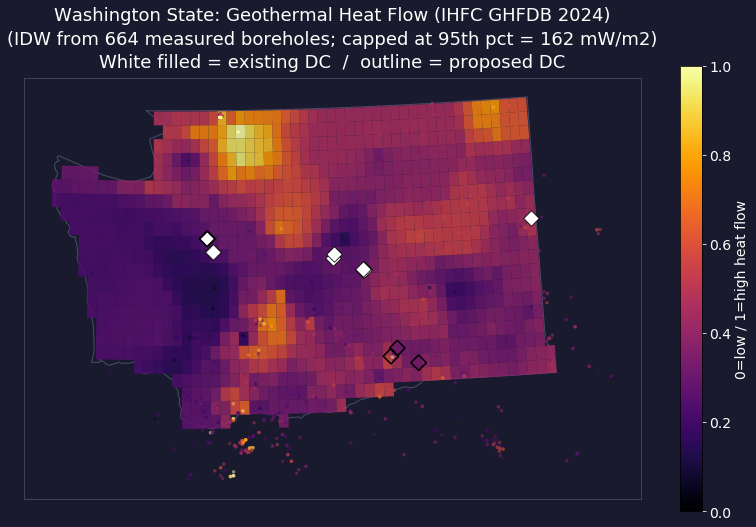

Saved to data/processed/geothermal.png


In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
wa.boundary.plot(ax=ax, color="#4a4a6a", linewidth=1.0, zorder=1)

n_before = len(fig.axes)
grid.plot(column="geothermal_score", ax=ax, cmap="inferno", vmin=0, vmax=1,
          legend=True,
          legend_kwds={"shrink": 0.65, "label": "0=low / 1=high heat flow"},
          alpha=0.85, zorder=2)
if len(fig.axes) > n_before:
    cb = fig.axes[-1]
    cb.tick_params(labelsize=14, colors=WHITE)
    cb.yaxis.label.set_color(WHITE)
    cb.yaxis.label.set_size(14)

# Scatter heat flow measurement points
hf_gdf_plot = hf_gdf.to_crs("EPSG:32610")
ax.scatter(hf_gdf_plot.geometry.x, hf_gdf_plot.geometry.y,
           c=hf_gdf_plot["q_capped"], cmap="inferno",
           s=12, alpha=0.5, zorder=3, linewidths=0)

_rep  = dc_gdf[dc_gdf["source"] == "reported"]
_prop = dc_gdf[dc_gdf["source"] == "proposed"]
ax.scatter(_rep.geometry.x,  _rep.geometry.y,
           c=WHITE, s=120, marker="D", zorder=5,
           edgecolors="black", linewidths=0.8)
ax.scatter(_prop.geometry.x, _prop.geometry.y,
           facecolors="none", s=120, marker="D", zorder=5,
           edgecolors="black", linewidths=1.5)

ax.set_title(
    "Washington State: Geothermal Heat Flow (IHFC GHFDB 2024)\n"
    "(IDW from 664 measured boreholes; capped at 95th pct = 162 mW/m2)\n"
    "White filled = existing DC  /  outline = proposed DC",
    color=WHITE, fontsize=18, pad=10, linespacing=1.4
)
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_edgecolor("#4a4a6a")

plt.tight_layout()
plt.savefig(PROCESSED / "geothermal.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved to data/processed/geothermal.png")


## 5. Export updated grid_scores.geojson


In [6]:
grid_out = grid.drop(columns=["centroid"]).to_crs("EPSG:4326")
grid_out.to_file("../static/grid_scores.geojson", driver="GeoJSON")
print(f"Saved ../static/grid_scores.geojson")
print(f"Columns: {list(grid_out.columns)}")


Saved ../static/grid_scores.geojson
Columns: ['cell_id', 'tx_score', 'water_score', 'ej_score', 'seismic_score', 'flood_score', 'contamination_score', 'waterway_score', 'geometry', 'geothermal_score']


## 6. Key Findings


In [7]:
print("=== Proposed Sites ===")
for _, row in dc_gdf[dc_gdf["source"] == "proposed"].iterrows():
    pt = row.geometry
    dists = grid.centroid.apply(lambda c: pt.distance(c))
    n = grid.loc[dists.idxmin()]
    q_val = n.geothermal_score * hf["q_capped"].max()
    print(f'  {row["name"]}:\n'
          f'    geothermal_score={n.geothermal_score:.3f}  '
          f'(~{q_val:.0f} mW/m2 interpolated)\n')

print("=== Existing Clusters (unique cells) ===")
seen = set()
for _, row in dc_gdf[dc_gdf["source"] == "reported"].iterrows():
    pt = row.geometry
    dists = grid.centroid.apply(lambda c: pt.distance(c))
    n = grid.loc[dists.idxmin()]
    key = round(n.geothermal_score, 3)
    if key not in seen:
        seen.add(key)
        q_val = n.geothermal_score * hf["q_capped"].max()
        print(f'  {row["name"]}:\n'
              f'    geothermal_score={n.geothermal_score:.3f}  '
              f'(~{q_val:.0f} mW/m2 interpolated)\n')


=== Proposed Sites ===
  Digital Realty (proposed):
    geothermal_score=0.257  (~42 mW/m2 interpolated)

  Amazon Wallula Gap (proposed):
    geothermal_score=0.339  (~55 mW/m2 interpolated)

  Atlas Agro Richland DC1 (proposed):
    geothermal_score=0.342  (~55 mW/m2 interpolated)

  Trammell Crow Lewis Clark (proposed):
    geothermal_score=0.560  (~91 mW/m2 interpolated)

=== Existing Clusters (unique cells) ===
  Microsoft Quincy Campus:
    geothermal_score=0.319  (~52 mW/m2 interpolated)

  Microsoft EAT06/EAT09:
    geothermal_score=0.318  (~52 mW/m2 interpolated)

  Equinix SE2 Seattle:
    geothermal_score=0.257  (~42 mW/m2 interpolated)

  HorizonIQ Seattle (Tukwila):
    geothermal_score=0.235  (~38 mW/m2 interpolated)

  Verizon Liberty Lake:
    geothermal_score=0.461  (~75 mW/m2 interpolated)

